# STORM — Motif characterization

Given the spatial motifs produced by **`01_train_storm_model.ipynb`**, this
notebook asks *what each motif is* and *how it differs between cancer and normal
tissue*:

1. **Cellular composition** — cell-type makeup of every motif.
2. **Marker genes** — genes enriched in each motif (Wilcoxon rank-sum,
   Benjamini–Hochberg FDR), as in the methods.
3. **Niche-embedding structure** — UMAP of the 20-D embeddings, coloured by motif.
4. **Abundance shift** — per-motif cancer-vs-normal abundance with a
   Mann–Whitney *U* test.

It reads only the `outputs/` produced by notebook 01 plus the example `.h5ad`.

In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sc.settings.verbosity = 0
warnings.filterwarnings("ignore")
DATA_DIR, OUT_DIR = "data/example", "outputs"

## 1. Assemble a per-cell table: expression + motif label

We re-read the example samples in the same order the pipeline used, apply the
same QC filter, and attach each cell's motif label from
`spatial_motifs_results.csv`. An assertion guarantees the rows stay aligned.

In [2]:
meta = pd.read_csv(os.path.join(OUT_DIR, "spatial_motifs_results.csv"))

adatas = []
for f in sorted(glob.glob(os.path.join(DATA_DIR, "*.h5ad"))):
    a = sc.read_h5ad(f)
    sc.pp.filter_cells(a, min_counts=10)          # same QC as training
    a.obs["Sample"] = os.path.basename(f)
    adatas.append(a)
adata = ad.concat(adatas, join="outer")
adata.obs_names_make_unique()

# Rows must line up with the motif table (no cells were dropped by QC here)
assert len(adata) == len(meta), (len(adata), len(meta))
assert (adata.obs["Sample"].values == meta["Sample"].values).all()

adata.obs["Spatial_Motif"] = pd.Categorical(meta["Spatial_Motif"].astype(str).values)
adata.obs["Condition"] = meta["Condition"].values
adata.obs["Patient"] = meta["Patient"].values

# Log-normalized expression for interpretable marker statistics
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
print(adata)

AnnData object with n_obs × n_vars = 7200 × 60
    obs: 'x_centroid', 'y_centroid', 'cell_type', 'condition', 'patient', 'n_counts', 'Sample', 'Spatial_Motif', 'Condition', 'Patient'
    uns: 'log1p'
    obsm: 'spatial'
    layers: 'counts'


## 2. Cellular composition of each motif

The synthetic data ships a ground-truth `cell_type` per cell, so we can read off
exactly which cell types each learned motif aggregates (in real data this is the
annotated cell type from the cell-typing step).

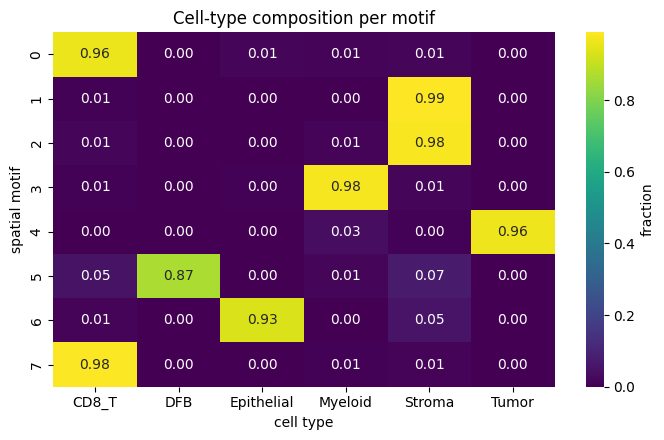

In [3]:
comp = (pd.crosstab(adata.obs["Spatial_Motif"], adata.obs["cell_type"], normalize="index"))
comp = comp.loc[sorted(comp.index, key=int)]
plt.figure(figsize=(7, 4.5))
sns.heatmap(comp, annot=True, fmt=".2f", cmap="viridis", cbar_kws={"label": "fraction"})
plt.xlabel("cell type"); plt.ylabel("spatial motif")
plt.title("Cell-type composition per motif")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "motif_celltype_composition.png"), dpi=150)
plt.show()

## 3. Motif marker genes (Wilcoxon rank-sum, BH-FDR)

`rank_genes_groups` ranks genes for each motif against the rest with the Wilcoxon
test and Benjamini–Hochberg correction — the same test the paper uses for motif
and cell-type differential expression.

In [4]:
sc.tl.rank_genes_groups(adata, "Spatial_Motif", method="wilcoxon")
top = pd.DataFrame({
    g: [f"{n} ({adata.uns['rank_genes_groups']['pvals_adj'][g][i]:.1e})"
        for i, n in enumerate(adata.uns["rank_genes_groups"]["names"][g][:5])]
    for g in adata.obs["Spatial_Motif"].cat.categories
})
top.index = [f"top{i+1}" for i in range(5)]
print("Top marker genes per motif (FDR in parentheses):")
top

Top marker genes per motif (FDR in parentheses):


,0,1,2,3,4,5,6,7
top1,CD81 (2.8e-305),STR3 (0.0e+00),STR1 (0.0e+00),MYE4 (0.0e+00),TUM2 (6.2e-281),DFB10 (1.2e-176),EPI7 (0.0e+00),CD82 (0.0e+00)
top2,CD84 (2.0e-297),STR7 (0.0e+00),STR9 (0.0e+00),MYE8 (0.0e+00),TUM10 (2.6e-280),DFB2 (1.2e-176),EPI1 (0.0e+00),CD810 (0.0e+00)
top3,CD89 (2.0e-297),STR1 (0.0e+00),STR5 (0.0e+00),MYE3 (0.0e+00),TUM1 (1.9e-278),DFB7 (3.2e-174),EPI10 (0.0e+00),CD88 (0.0e+00)
top4,CD88 (3.9e-297),STR6 (0.0e+00),STR8 (0.0e+00),MYE7 (0.0e+00),TUM7 (1.9e-278),DFB6 (3.5e-172),EPI2 (0.0e+00),CD87 (0.0e+00)
top5,CD86 (1.1e-294),STR2 (0.0e+00),STR10 (0.0e+00),MYE5 (0.0e+00),TUM6 (8.1e-278),DFB8 (4.2e-172),EPI9 (0.0e+00),CD83 (0.0e+00)


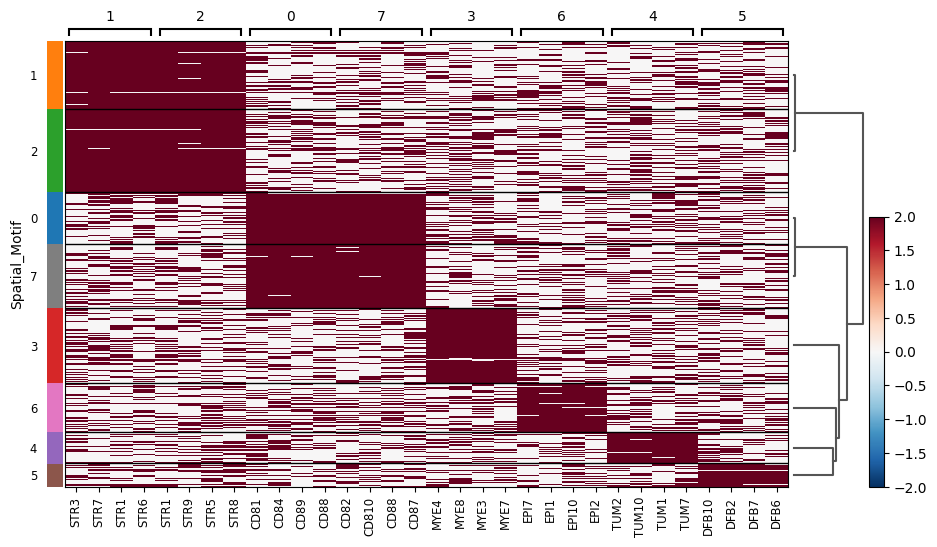

In [5]:
sc.pl.rank_genes_groups_heatmap(adata, n_genes=4, groupby="Spatial_Motif",
                                show_gene_labels=True, cmap="RdBu_r", vmin=-2, vmax=2,
                                show=False)
plt.savefig(os.path.join(OUT_DIR, "motif_marker_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

## 4. Niche-embedding structure (UMAP)

UMAP of the 20-D niche embeddings. Cells that share a motif should occupy
coherent regions of the embedding space.

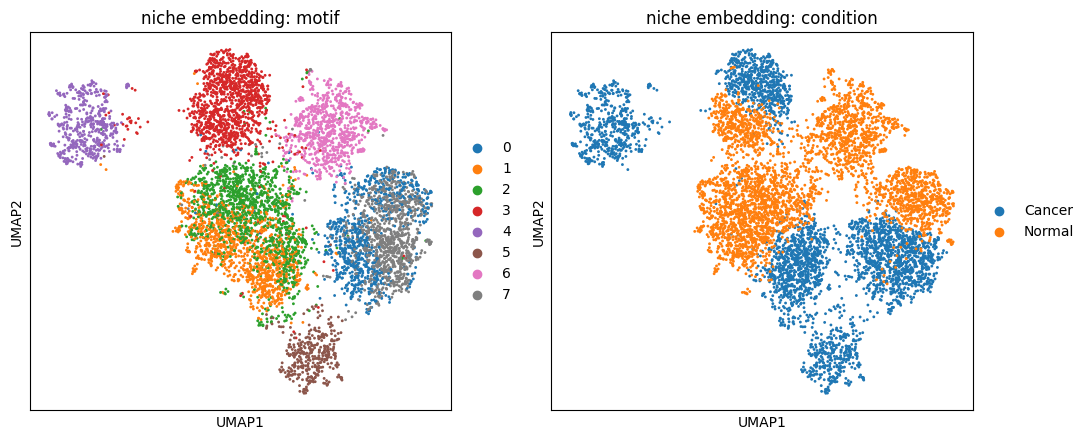

In [6]:
emb = np.load(os.path.join(OUT_DIR, "cell_niche_embeddings.npy"))
emb_ad = ad.AnnData(emb, obs=adata.obs.copy())
sc.pp.neighbors(emb_ad, use_rep="X", n_neighbors=15)
sc.tl.umap(emb_ad, random_state=42)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
sc.pl.umap(emb_ad, color="Spatial_Motif", ax=ax[0], show=False, title="niche embedding: motif")
sc.pl.umap(emb_ad, color="Condition", ax=ax[1], show=False, title="niche embedding: condition")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "niche_embedding_umap.png"), dpi=150, bbox_inches="tight")
plt.show()

## 5. Cancer-vs-normal motif abundance

For each sample we compute the fraction of cells in every motif, then test each
motif's cancer-vs-normal abundance with a Mann–Whitney *U* test, BH-correcting
across motifs (matching the compositional-comparison methods).

In [7]:
frac = (adata.obs.groupby(["Sample", "Condition", "Spatial_Motif"], observed=True)
        .size().rename("n").reset_index())
totals = frac.groupby("Sample")["n"].transform("sum")
frac["fraction"] = frac["n"] / totals

rows = []
for motif in sorted(adata.obs["Spatial_Motif"].cat.categories, key=int):
    sub = frac[frac["Spatial_Motif"] == motif]
    ca = sub[sub["Condition"] == "Cancer"]["fraction"]
    nl = sub[sub["Condition"] == "Normal"]["fraction"]
    # reindex missing (motif absent in a sample) as 0
    samples = adata.obs["Sample"].unique()
    f_by_sample = sub.set_index("Sample")["fraction"]
    ca_v = [f_by_sample.get(s, 0.0) for s in samples if "CA" in s]
    nl_v = [f_by_sample.get(s, 0.0) for s in samples if "NL" in s]
    stat, p = mannwhitneyu(ca_v, nl_v, alternative="two-sided")
    rows.append({"motif": motif, "mean_CA": np.mean(ca_v), "mean_NL": np.mean(nl_v), "p": p})

res = pd.DataFrame(rows)
res["FDR"] = multipletests(res["p"], method="fdr_bh")[1]
res = res.sort_values("FDR")
res

,motif,mean_CA,mean_NL,p,FDR
0,0,0.147500,0.083333,0.100000,0.1
1,1,0.136944,0.168333,0.100000,0.1
2,2,0.109444,0.263611,0.100000,0.1
3,3,0.193333,0.146111,0.076523,0.1
4,4,0.139444,0.000000,0.063603,0.1
5,5,0.105000,0.000000,0.059346,0.1
6,6,0.000000,0.219722,0.063603,0.1
7,7,0.168333,0.118889,0.100000,0.1


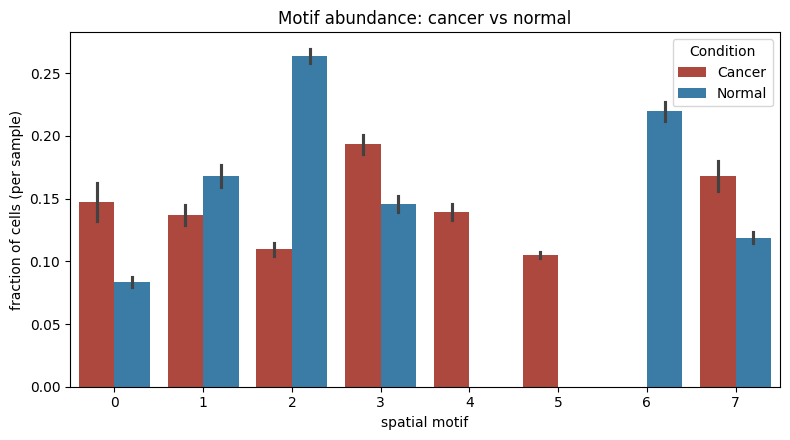

In [8]:
order = [str(m) for m in res.sort_values("motif")["motif"]]
plt.figure(figsize=(8, 4.5))
sns.barplot(data=frac, x="Spatial_Motif", y="fraction", hue="Condition",
            order=order, errorbar="se", palette={"Cancer": "#c0392b", "Normal": "#2980b9"})
plt.ylabel("fraction of cells (per sample)"); plt.xlabel("spatial motif")
plt.title("Motif abundance: cancer vs normal")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "motif_abundance_ca_vs_nl.png"), dpi=150)
plt.show()

On the synthetic cohort, tumour-core / barrier motifs are enriched in cancer
and crypt/stroma motifs in normal — the same kind of compositional contrast the
real STORM analysis quantifies, here recoverable end-to-end from the example
data.